# Deep Learning for Natural Language Processing

## Angelos Dorotheos Chatzopoulos
## 7115112400027

### Python packages PIP installs

In [39]:
%pip install gensim
%pip install pandas
%pip install numpy
%pip install nltk
%pip install contractions
%pip install wordcloud
%pip install IPython
%pip install scikit-learn
%pip install matplotlib
%pip install torch
%pip install optuna

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Python Packages Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from wordcloud import WordCloud
import re

import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import ngrams
import contractions
import string

import warnings
import sys
import os

if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore::UserWarning"

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.models import KeyedVectors
from nltk.tokenize import word_tokenize

import optuna

## Exploratory Data Analysis (EDA)

### Function that plots a pie chart of the percentage of positive and negative labels of datasets

In [3]:
def plot_pie_chart(counts, title):
    counts = pd.Series(counts)
    counts.plot(kind='pie', autopct='%1.2f%%', figsize=(8, 8), colors=['darkorange', 'royalblue'])
    plt.title(title)
    plt.ylabel('Labels Distribution')
    plt.show()

### Function that plots a histogram that shows the distribution of tweets length across the dataset

In [4]:
def plot_histogram(data, x_label, y_label, title):
    plt.figure(figsize=(8, 6))
    plt.hist(data, bins=list(np.arange(0, 40, 5)), edgecolor='black', color='royalblue')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.xlim(0, 50)
    plt.axvline(data.mean(), color='k', linestyle='dashed', linewidth=1)
    _, max_ylim = plt.ylim()
    plt.text(data.mean()*1.1, max_ylim*0.9, 'Mean: {:.2f}'.format(data.mean()))
    plt.tight_layout()
    plt.show()

### Function that plots a wordcloud with the most common words of the dataset

In [5]:
def create_wordcloud(text):
    all_text = " ".join(text)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
    plt.figure(figsize=(12, 10))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()

### Function that plots a bar graph. Used for min-max tweets length and for finding the most common unigrams of the dataset

In [6]:
def plot_bar(categories, values, x_label, y_label, title, rotate=False, log_scale=False, show_vals=False, bary=False):
    plt.figure(figsize=(8, 6))
    
    if bary:
        bars = plt.barh(categories, values, edgecolor='black', color='royalblue')
    else:
        bars = plt.bar(categories, values, edgecolor='black', color='royalblue')
        
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    
    if show_vals:
         for bar in bars:
            plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + bar.get_height() * 0.01, bar.get_height(),
                ha='center', va='bottom', color='black', fontsize=10)

    if log_scale:
        plt.yscale('log')

    if rotate:
        plt.xticks(rotation=-60)
        
    plt.tight_layout()
    plt.show()

### Function that plots two bar graphs. It is used to count the tweets bigrams and trigrams on the dataset

In [5]:
def subplot_bars(plot_1_values, plot_2_values, title, rotate=False, bary=False):
    _, axis = plt.subplots(1, 2, figsize=(18, 8))
    
    plt.suptitle(title, fontsize=15)
    
    if bary:
        axis[0].barh(plot_1_values[0], plot_1_values[1], edgecolor='black', color='royalblue')
    else:
        axis[0].bar(plot_1_values[0], plot_1_values[1], edgecolor='black', color='royalblue')

    axis[0].set_xlabel(plot_1_values[2])
    axis[0].set_ylabel(plot_1_values[3])
    
    if rotate:
        axis[0].tick_params(axis='x', labelrotation =-60)
    
    if bary:
        axis[1].barh(plot_2_values[0], plot_2_values[1], edgecolor='black', color='royalblue')
    else:
        axis[1].bar(plot_2_values[0], plot_2_values[1], edgecolor='black', color='royalblue')

    axis[1].set_xlabel(plot_2_values[2])
    axis[1].set_ylabel(plot_2_values[3])

    if rotate:
        axis[1].tick_params(axis='x', labelrotation =-60)
    
    plt.tight_layout()
    plt.show()

### Function that calculates for each row the length of the tweet text

In [7]:
def get_tweets_length(df):
    return df['Text'].str.split().str.len()

### Function that calculates and returns the top n-grams of a dataframe

In [8]:
def get_top_tokens(df, top, n=1):
    count_phrases = [word for tweet in df['Text'] for word in tweet.split()]
    ngram_2_tweets = pd.Series([word for word in ngrams(count_phrases, n)]).value_counts()
    top_10_phrases = ngram_2_tweets[:top]

    top_10_tokens_names = [' '.join(x) for x in top_10_phrases.index]
    top_10_tokens_freq = list(top_10_phrases)
    return top_10_tokens_names, top_10_tokens_freq

### Function that finds the minimum and maximum tweet length and returns a new dataframe

In [9]:
def get_min_max_tweets(t_length):
    return pd.DataFrame({
        'Minimum Tweet Length': [t_length.min()],
        'Maximum Tweet Length': [t_length.max()],
    })

### Load train, validation and test datasets from CSV files into dataframes

In [10]:
df_train = pd.read_csv('./data/train_dataset.csv')
df_val = pd.read_csv('./data/val_dataset.csv')
df_test = pd.read_csv('./data/test_dataset.csv')

### Extract tweets and labels from the dataframes

In [13]:
X_train, y_train = df_train['Text'], df_train['Label']

X_val, y_val = df_val['Text'], df_val['Label']

X_test = df_test['Text']

### Displaying the dimensions of dataframes

In [14]:
print(f'Training dataset dimensions: {df_train.shape}')
print(f'Validate dataset dimensions: {df_val.shape}')
print(f'Test dataset dimensions: {df_test.shape}')

Training dataset dimensions: (148388, 3)
Validate dataset dimensions: (42396, 3)
Test dataset dimensions: (21199, 2)


### Displaying metadata information about Train dataframe

In [15]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148388 entries, 0 to 148387
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   ID      148388 non-null  int64 
 1   Text    148388 non-null  object
 2   Label   148388 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.4+ MB


### Displaying metadata information about Validation dataframe

In [15]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42396 entries, 0 to 42395
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      42396 non-null  int64 
 1   Text    42396 non-null  object
 2   Label   42396 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 993.8+ KB


### Checking the top 5 rows of the train set

In [16]:
df_train.head()

,ID,Text,Label
0,189385,@whoisralphie dude I'm so bummed ur leaving!,0
1,58036,"oh my god, a severed foot was foun in a wheely...",0
2,190139,I end up &quot;dog dialing&quot; sumtimes. Wha...,1
3,99313,@_rachelx meeeee toooooo!,0
4,157825,"I was hoping I could stay home and work today,...",0


### Checking the top 5 rows of the validation set

In [17]:
df_val.head()

,ID,Text,Label
0,187062,@NatexTheGreat heyheyhey maybe i will get the...,0
1,168997,@molliesmummy Work? Work was crap. I missed yo...,0
2,194461,Want: Trip to Boston next month. Need: Addit'l...,1
3,165442,first day starts tomorrow!,1
4,34853,@goodforyoursoul 8 course fish in Little Saigo...,1


### We observe that train & validation datasets do not have any empty or duplicated rows

In [18]:
print('Train Set')
display(df_train.isnull().sum())
display(df_train.duplicated().sum())

print('Validation Set')
display(df_val.isnull().sum())
display(df_val.duplicated().sum())

Train Set


ID       0
Text     0
Label    0
dtype: int64

0

Validation Set


ID       0
Text     0
Label    0
dtype: int64

0

## Exploratory Data Analysis Before Text Preprocessing

### Plotting the distribution of sentiment categories in dataset. We notice that positive & negative labels are equally distributed

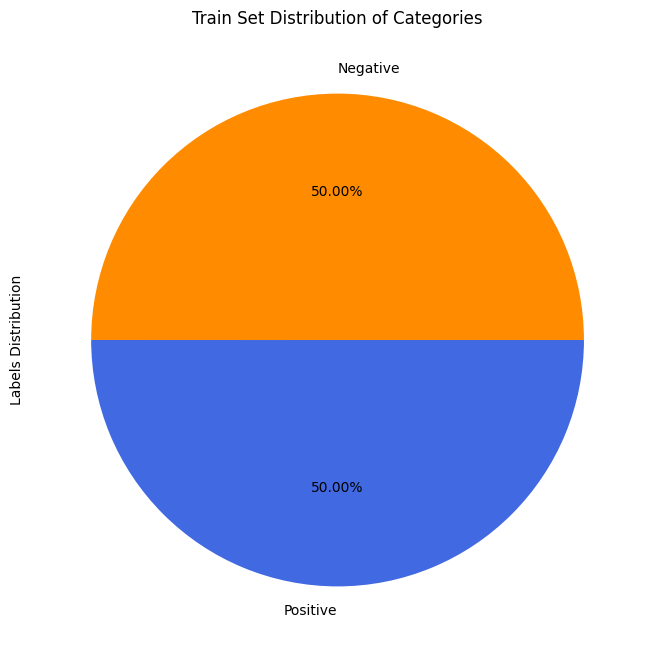

In [19]:
labels_count = df_train['Label'].value_counts()
negative_tweets = labels_count[0]
positive_tweets = labels_count[1]

plot_pie_chart({'Negative': negative_tweets, 'Positive': positive_tweets}, 'Train Set Distribution of Categories')

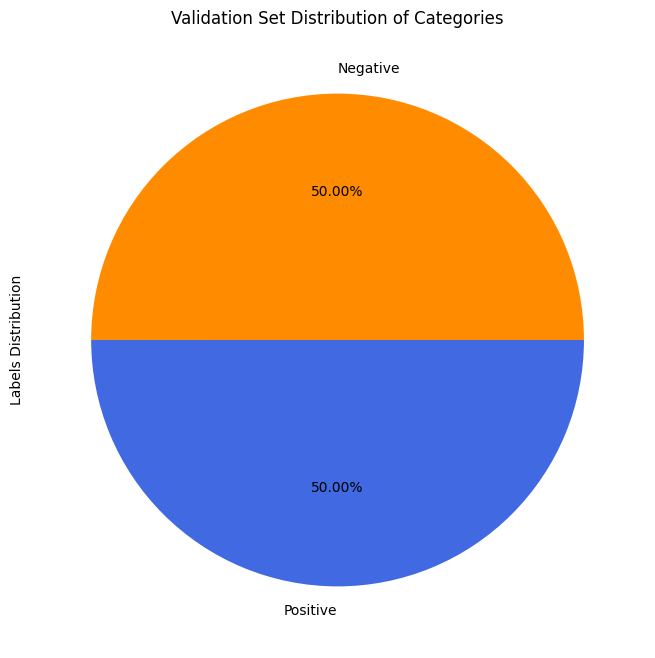

In [20]:
labels_count = df_val['Label'].value_counts()
negative_tweets = labels_count[0]
positive_tweets = labels_count[1]

plot_pie_chart({'Negative': negative_tweets, 'Positive': positive_tweets}, 'Validation Set Distribution of Categories')

### Creating a wordcloud using the tweet texts on train set before preprocessing

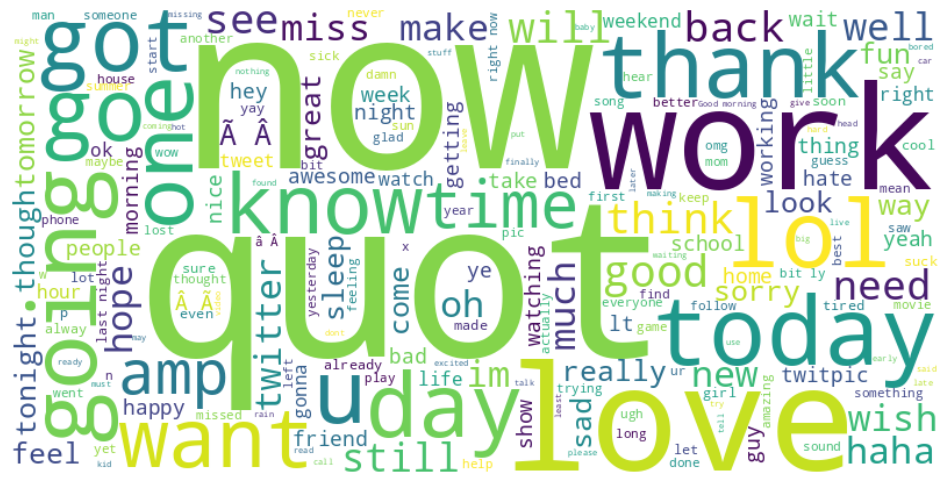

In [21]:
create_wordcloud(df_train['Text'])

### Creating a wordcloud by using only the positive tweets before preprocessing

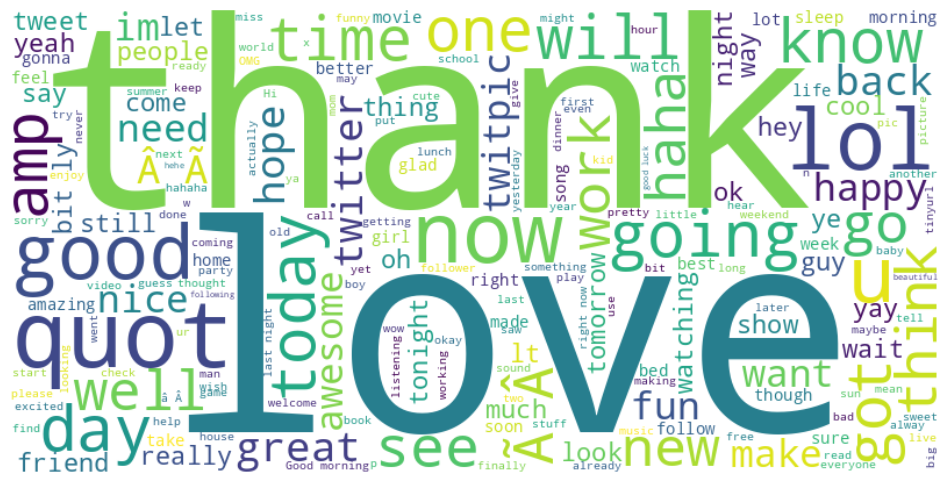

In [22]:
create_wordcloud(df_train[df_train['Label'] == 1]['Text'])

### Creating a wordcloud by using only the negative tweets before preprocessing

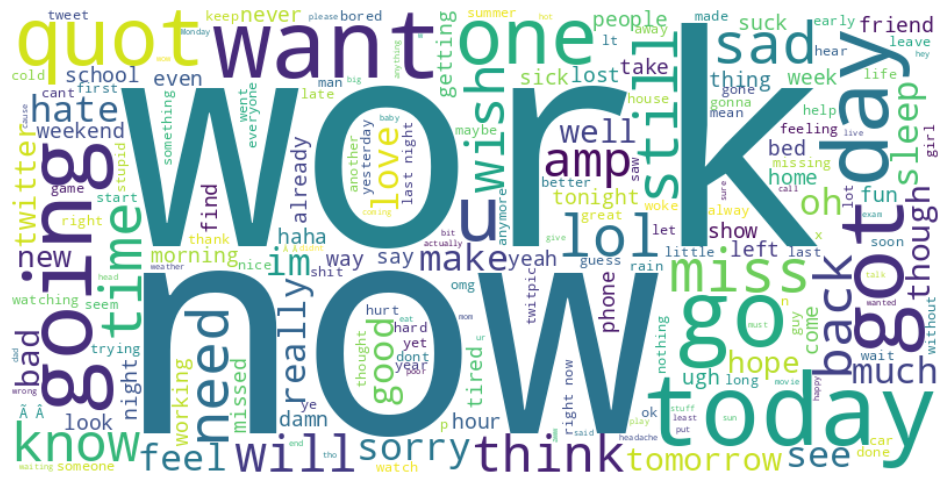

In [23]:
create_wordcloud(df_train[df_train['Label'] == 0]['Text'])

### Plotting a histogram with tweets length across the dataset

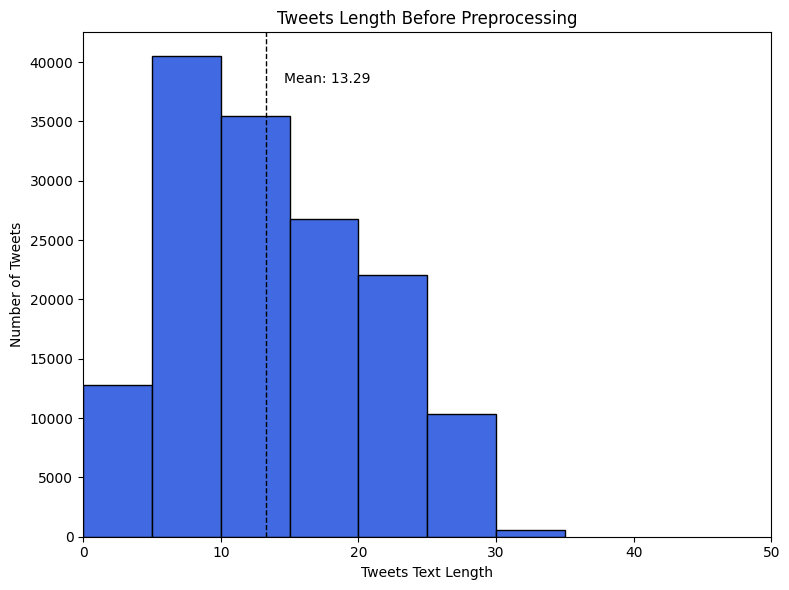

In [24]:
tweets_length = get_tweets_length(df_train)
plot_histogram(tweets_length, 'Tweets Text Length', 'Number of Tweets', 'Tweets Length Before Preprocessing')

### Plotting minimum and maximum length of tweets on train set

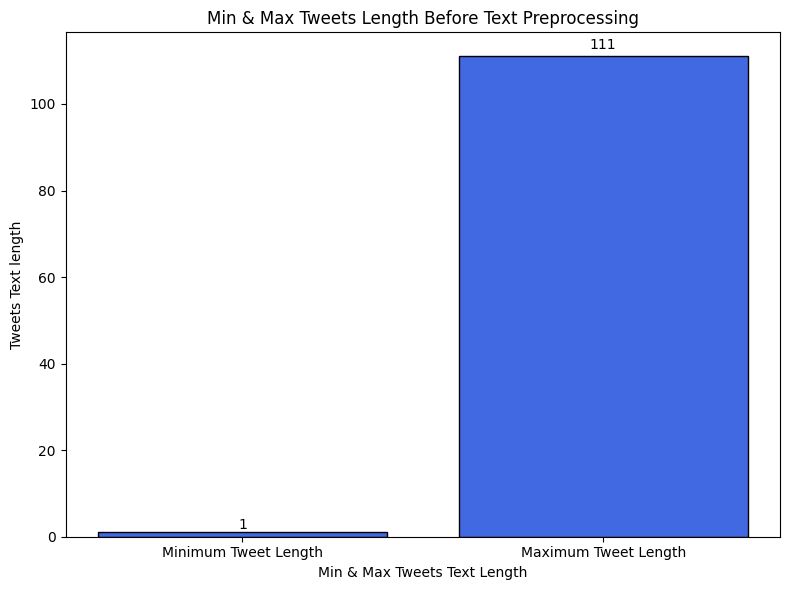

In [25]:
df_min_max = get_min_max_tweets(tweets_length)
plot_bar(list(df_min_max.columns), df_min_max.iloc[0, :].values.tolist(), 'Min & Max Tweets Text Length', 'Tweets Text length', 'Min & Max Tweets Length Before Text Preprocessing', False, False, True)

### Plotting the most common words (unigrams) of train dataset

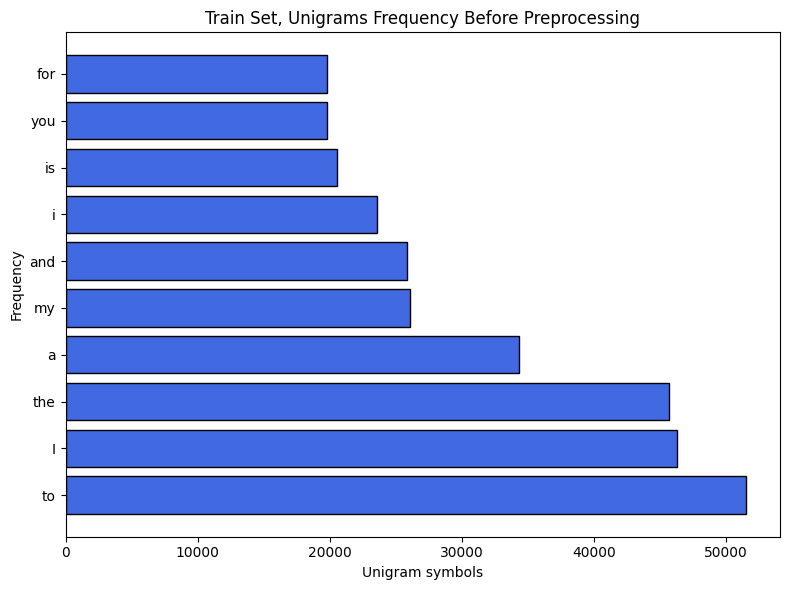

In [26]:
bar_plots_1ngrams = [res for res in get_top_tokens(df_train, top=10, n=1)] + ['Unigram symbols', 'Frequency']
plot_bar(bar_plots_1ngrams[0], bar_plots_1ngrams[1], bar_plots_1ngrams[2], bar_plots_1ngrams[3], 'Train Set, Unigrams Frequency Before Preprocessing', bary=True)

### Plotting the most common tokens (bigrams and trigrams) of train dataset

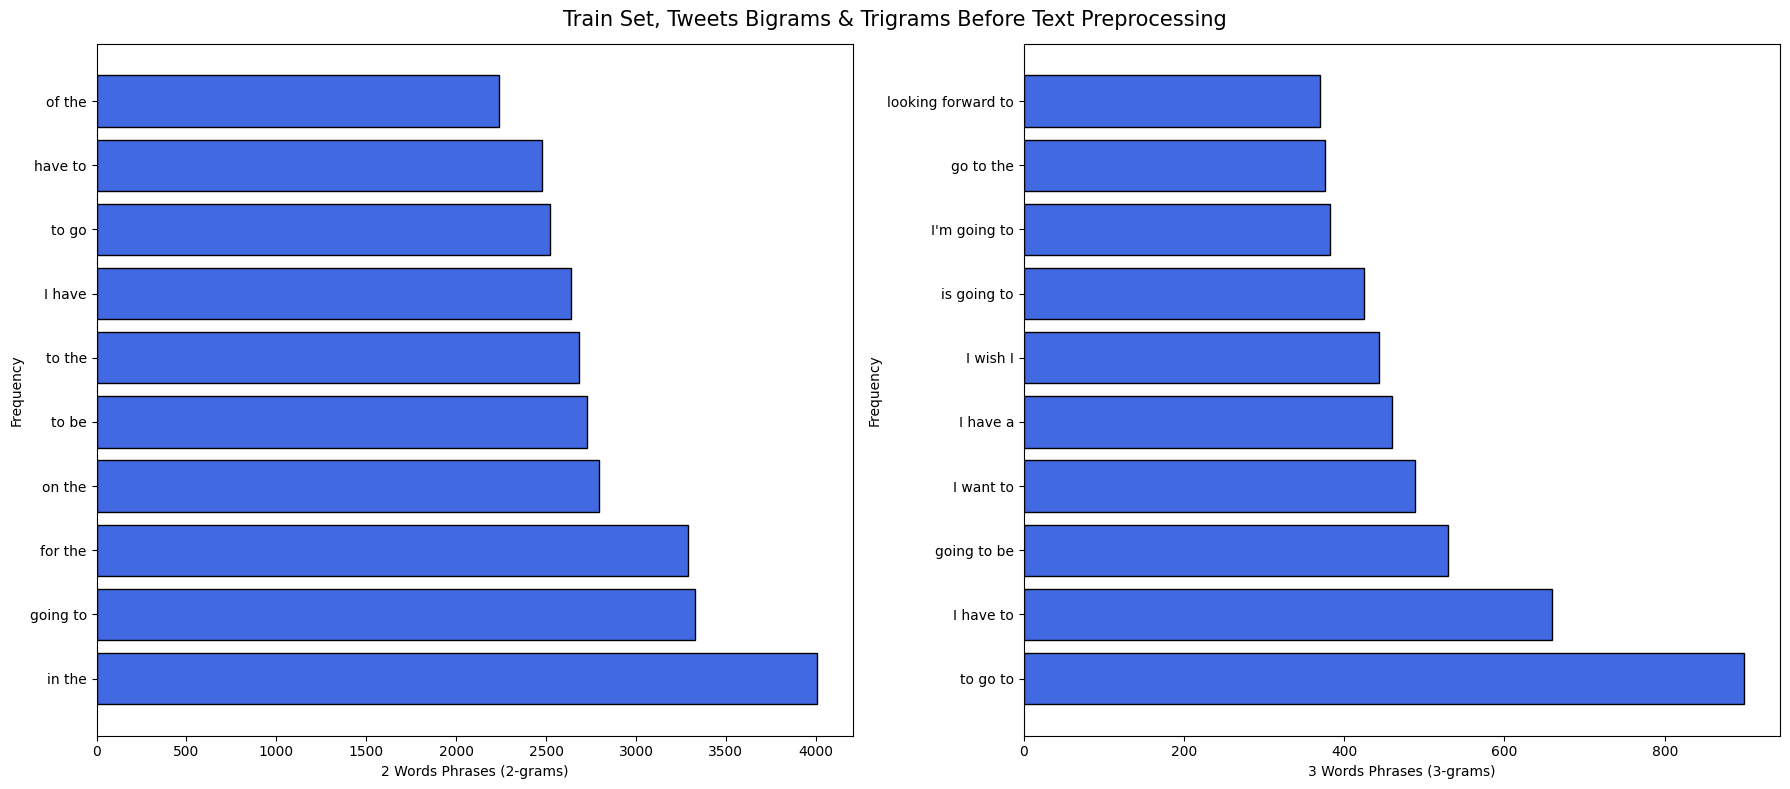

In [27]:
bar_plots_2ngrams = [res for res in get_top_tokens(df_train, top=10, n=2)] + ['2 Words Phrases (2-grams)', 'Frequency']
bar_plots_3ngrams = [res for res in get_top_tokens(df_train, top=10, n=3)] + ['3 Words Phrases (3-grams)', 'Frequency']

subplot_bars(bar_plots_2ngrams, bar_plots_3ngrams, 'Train Set, Tweets Bigrams & Trigrams Before Text Preprocessing', bary=True)

### Plotting the number of emails and user mentions found in train dataset (Log Scale)

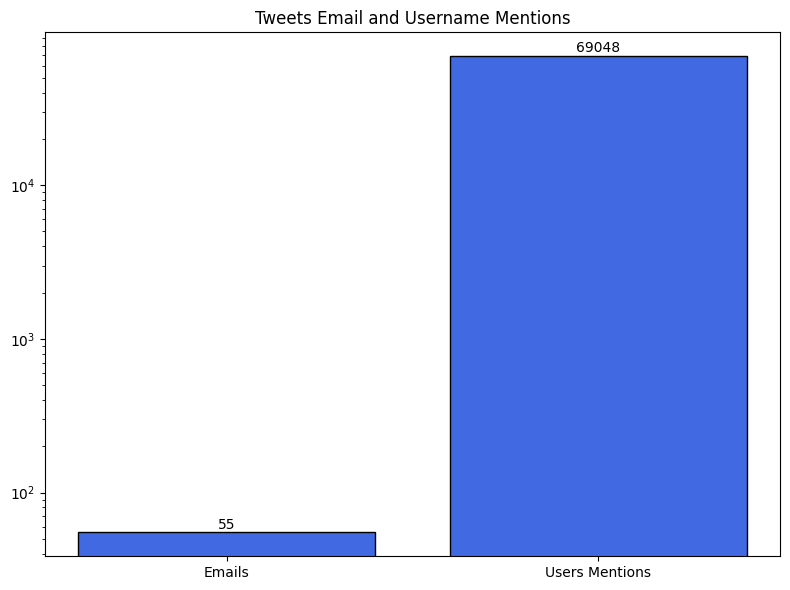

In [28]:
emails_count = df_train.loc[df_train['Text'].str.contains(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{1,}\b'), :].shape[0]

user_mentions_count = df_train.loc[df_train['Text'].str.contains(r'(?<![\w.])@\w+'), :].shape[0]

plot_bar(['Emails', 'Users Mentions'], [emails_count, user_mentions_count], '', '', 'Tweets Email and Username Mentions', False, True, True)

## NLP Text Preprocessing on Tweets

In [16]:
nltk.download('punkt', quiet=True);
nltk.download('stopwords', quiet=True);
nltk.download('wordnet', quiet=True);

### Text Preprocessing is done on two phases:
- Preprocessing with stop words filtering
- Preprocessing with stop words preservation

### The `preprocess_text` function applies the following preprocessing steps:
- **Lowercasing**: Converts all characters to lowercase.
- **Expanding Contractions**: Expanding combinations of words that are shortened.
- **Removing Punctuation Except '@' for Emails and User Mentions**: Eliminating the punctuation of tweets.
- **Anonymizing Mentions**: Username mentions in tweets are converted to '@user'.
- **Anonymizing Email Addresses**: Email addresses are converted to 'XXX@email.com'.
- **Removing URLs**: Removing URLs from text.
- **Removing Digits**: Removing all numeric characters within tweets.
- **Filtering Stop Words**: If 'filter_stopwords' is true then stop words are removed from tweets.
- **Lemmatization**: Coverts the words to their base form.

In [17]:
punctuation = string.punctuation.replace('@', '')
lemmatizer = WordNetLemmatizer()
tokenizer = TweetTokenizer()

def preprocess_text(text, filter_stopwords):
    text = text.lower()
    text = contractions.fix(text)
    
    text = text.translate(str.maketrans('', '', punctuation))

    text = re.sub(r'(?<![\w.])@\w+', '@user', text)
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\b', "XXX@email.com", text)
    
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r'\d+', '', text)
    
    tokens = tokenizer.tokenize(text)
    
    if filter_stopwords:
        stop_words = set(stopwords.words('english'))
        tokens = [word for word in tokens if word not in stop_words]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return ' '.join(tokens)

### Removing rows with zero text length (after doing preprocessing) only on train and validation datasets

In [18]:
def filter_non_empty(df):
    return df[df['Text'].str.split().str.len() != 0]

### Function `clean_dataset` does the following steps:
- Creates a copy of the dataframe.
- Removes non-ascii characters from tweets.
- Runs the `preprocess_text` function to further preprocess the tweets (explained above).
- Removes any row with zero text length (on train and validation set only).

In [19]:
def clean_dataset(df, filter_stopwords=False, filter_rows=True):
    df_clean = df.copy()
    df_clean['Text'] = df_clean['Text'].str.encode('ascii', 'ignore').str.decode('ascii')
    df_clean['Text'] = df_clean['Text'].apply(preprocess_text, filter_stopwords=filter_stopwords)
    return filter_non_empty(df_clean) if filter_rows else df_clean

### Running tweets preprocessing on train, validation and test set with filtering stop words activated

In [20]:
df_train_cln = clean_dataset(df_train, filter_stopwords=True)
df_val_cln = clean_dataset(df_val, filter_stopwords=True)
df_test_cln = clean_dataset(df_test, filter_stopwords=True, filter_rows=False)

X_train_prep, y_train_prep = df_train_cln['Text'], df_train_cln['Label']
X_val_prep, y_val_prep   = df_val_cln['Text'], df_val_cln['Label']
X_test_prep = df_test_cln['Text']

### Displaying the dimenstions of train, validation and test dataset matrices

In [21]:
print(f"X train Preprocessed Dimensions: {X_train_prep.shape}")
print(f"y train Preprocessed Dimensions: {y_train_prep.shape}")

print(f"X validation Preprocessed Dimensions: {X_val_prep.shape}")
print(f"y validation Preprocessed Dimensions: {y_val_prep.shape}")

print(f"X test Preprocessed Dimensions: {X_test_prep.shape}")

X train Preprocessed Dimensions: (148339,)
y train Preprocessed Dimensions: (148339,)
X validation Preprocessed Dimensions: (42385,)
y validation Preprocessed Dimensions: (42385,)
X test Preprocessed Dimensions: (21199,)


### Checking the tweets after running preprocessing

In [21]:
df_train_cln.head()

,ID,Text,Label
0,189385,@user dude bummed leaving,0
1,58036,oh god severed foot foun wheely bin cobham fou...,0
2,190139,end quotdog dialingquot sumtimes dog dialing a...,1
3,99313,@user meeeee toooooo,0
4,157825,hoping could stay home work today look like ma...,0


In [22]:
df_val_cln.head()

,ID,Text,Label
0,187062,@user heyheyhey maybe get could find @user wou...,0
1,168997,@user work work crap missed condescending over...,0
2,194461,want trip boston next month need additl motiva...,1
3,165442,first day start tomorrow,1
4,34853,@user course fish little saigon dessert place ...,1


## Exploratory Data Analysis After Running Text Preprocessing (With Stop Words Filtering)

### Plotting a histogram with tweets length across the training dataset after preprocessing

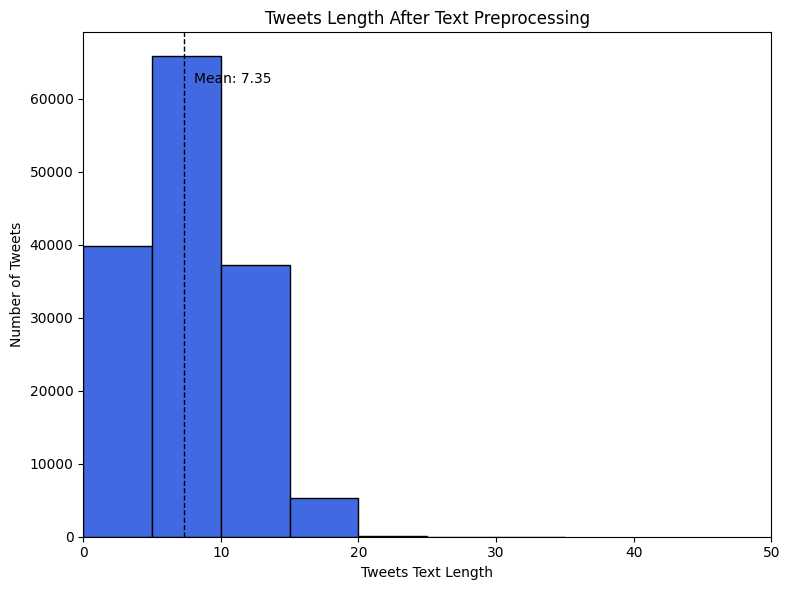

In [37]:
tweets_length_clean = get_tweets_length(df_train_cln)
plot_histogram(tweets_length_clean, 'Tweets Text Length', 'Number of Tweets', 'Tweets Length After Text Preprocessing')

### Plotting minimum and maximum length of tweets after running preprocessing

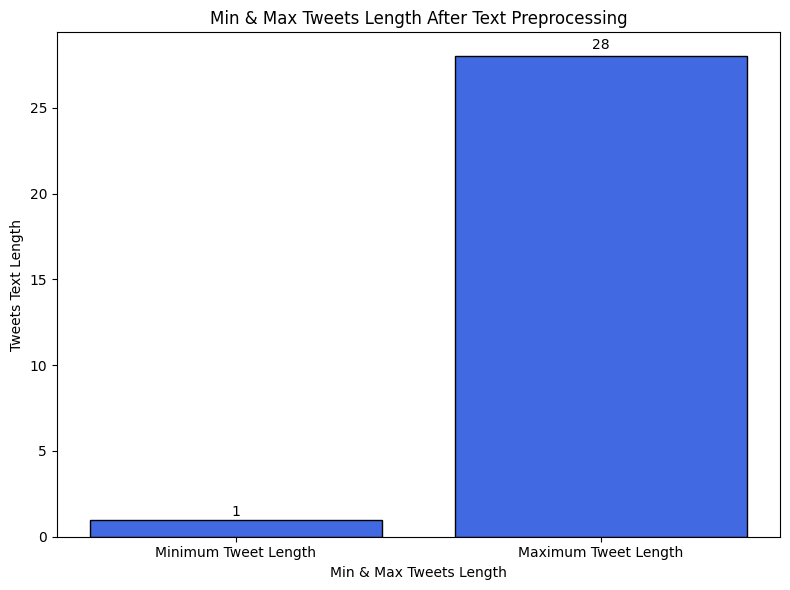

In [38]:
df_min_max = get_min_max_tweets(tweets_length_clean)
plot_bar(list(df_min_max.columns), df_min_max.iloc[0, :].values.tolist(), 'Min & Max Tweets Length', 'Tweets Text Length', 'Min & Max Tweets Length After Text Preprocessing', False, False, True)

### Creating a wordcloud using the tweet texts on train set after running preprocessing

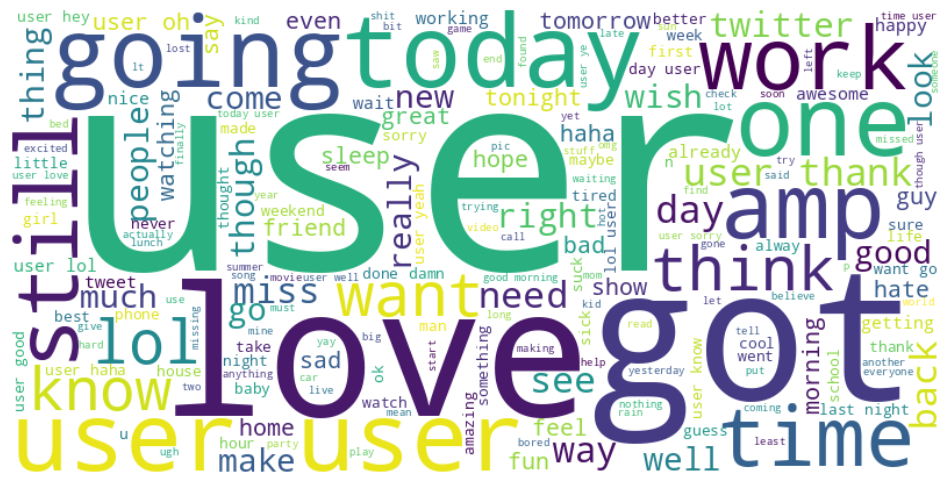

In [39]:
create_wordcloud(df_train_cln['Text'])

### Creating a wordcloud by using only the positive tweets after running preprocessing

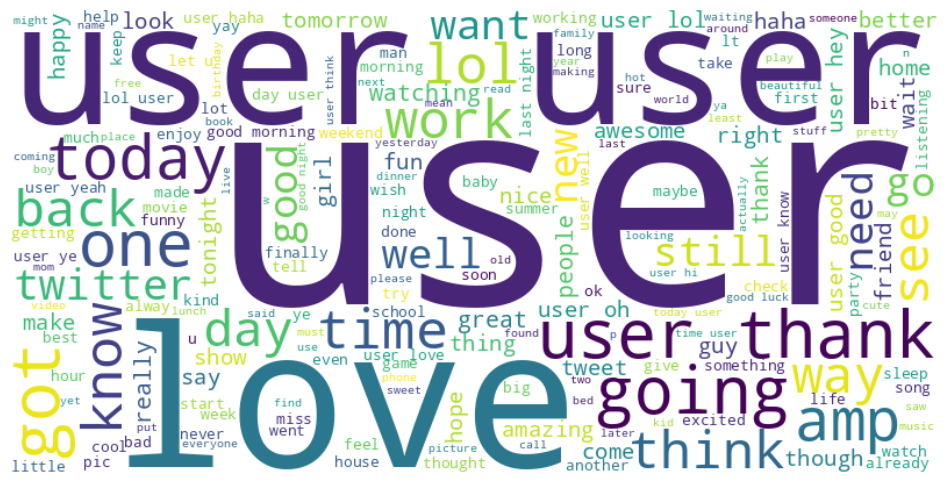

In [40]:
create_wordcloud(df_train_cln[df_train_cln['Label'] == 1]['Text'])

### Creating a wordcloud by using only the negative tweets after running preprocessing

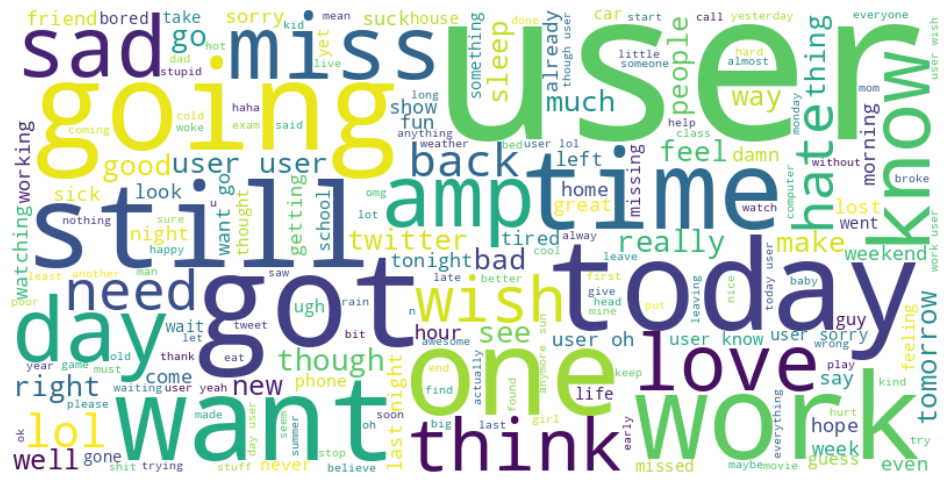

In [41]:
create_wordcloud(df_train_cln[df_train_cln['Label'] == 0]['Text'])

### Plotting the most common words (unigrams) of train dataset after running preprocessing

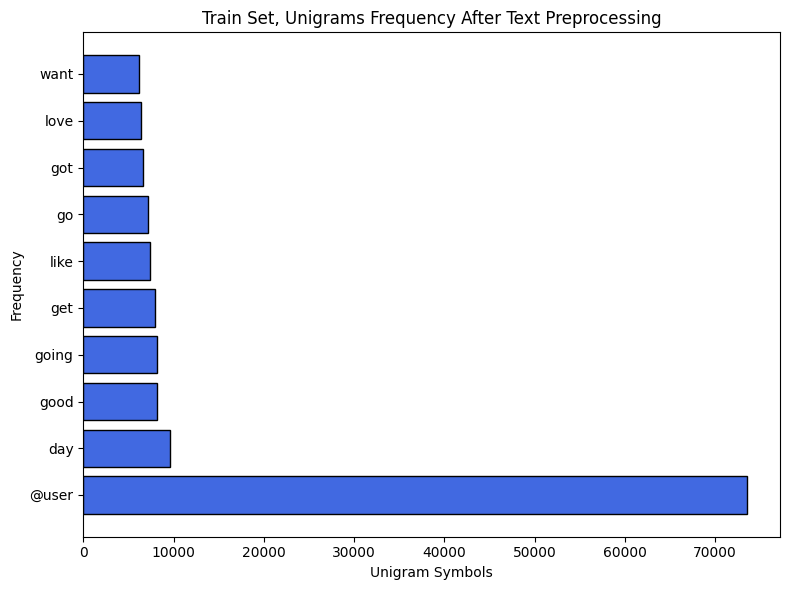

In [42]:
bar_plots_1ngrams = [res for res in get_top_tokens(df_train_cln, top=10, n=1)] + ['Unigram Symbols', 'Frequency']
plot_bar(bar_plots_1ngrams[0], bar_plots_1ngrams[1], bar_plots_1ngrams[2], bar_plots_1ngrams[3], 'Train Set, Unigrams Frequency After Text Preprocessing', bary=True)

### Plotting the most common tokens (bigrams and trigrams) of train dataset after running preprocessing

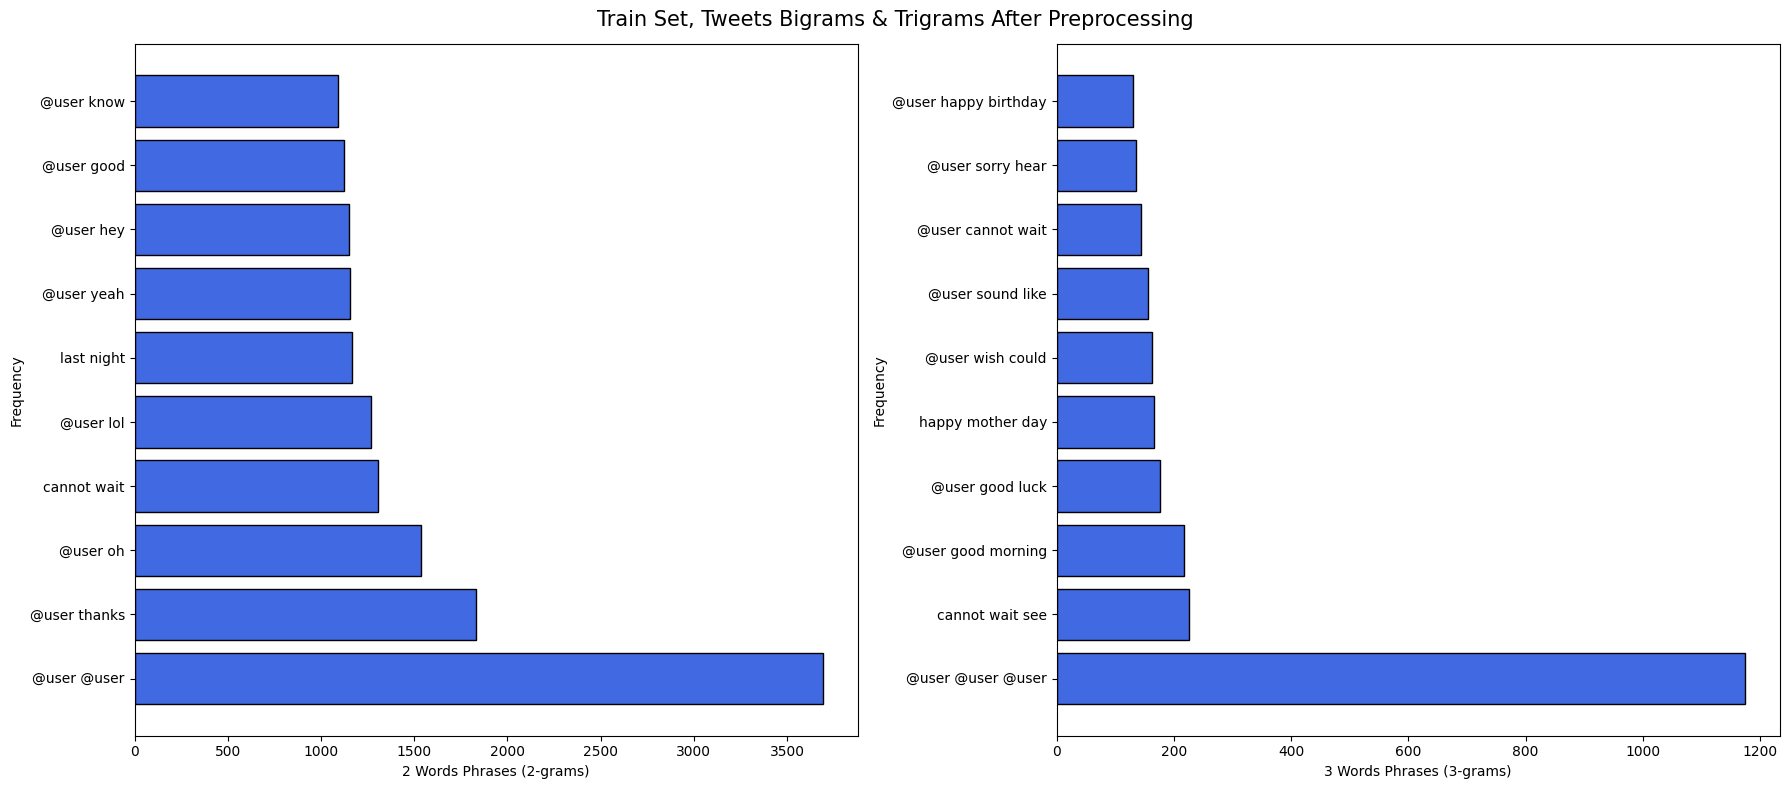

In [43]:
bar_plots_2ngrams = [res for res in get_top_tokens(df_train_cln, top=10, n=2)] + ['2 Words Phrases (2-grams)', 'Frequency']
bar_plots_3ngrams = [res for res in get_top_tokens(df_train_cln, top=10, n=3)] + ['3 Words Phrases (3-grams)', 'Frequency']

subplot_bars(bar_plots_2ngrams, bar_plots_3ngrams, 'Train Set, Tweets Bigrams & Trigrams After Preprocessing', bary=True)

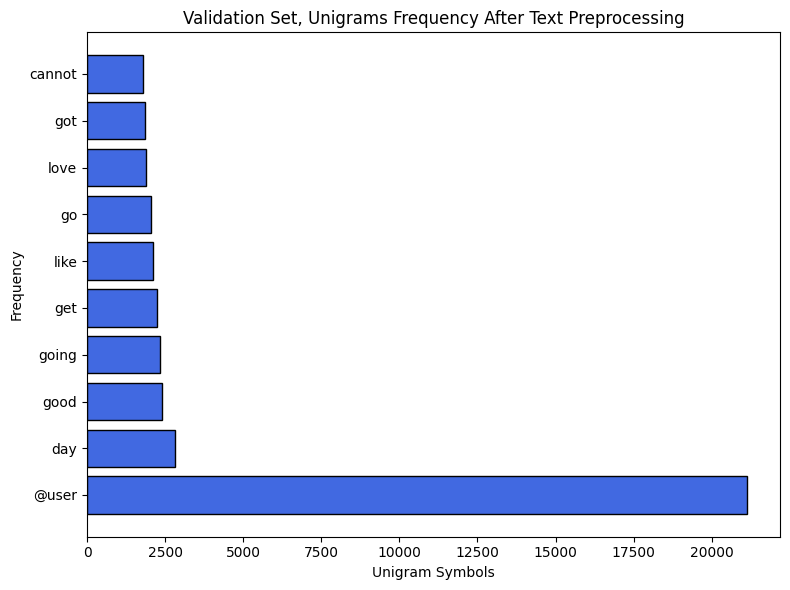

In [44]:
bar_plots_1ngrams = [res for res in get_top_tokens(df_val_cln, top=10, n=1)] + ['Unigram Symbols', 'Frequency']
plot_bar(bar_plots_1ngrams[0], bar_plots_1ngrams[1], bar_plots_1ngrams[2], bar_plots_1ngrams[3], 'Validation Set, Unigrams Frequency After Text Preprocessing', bary=True)

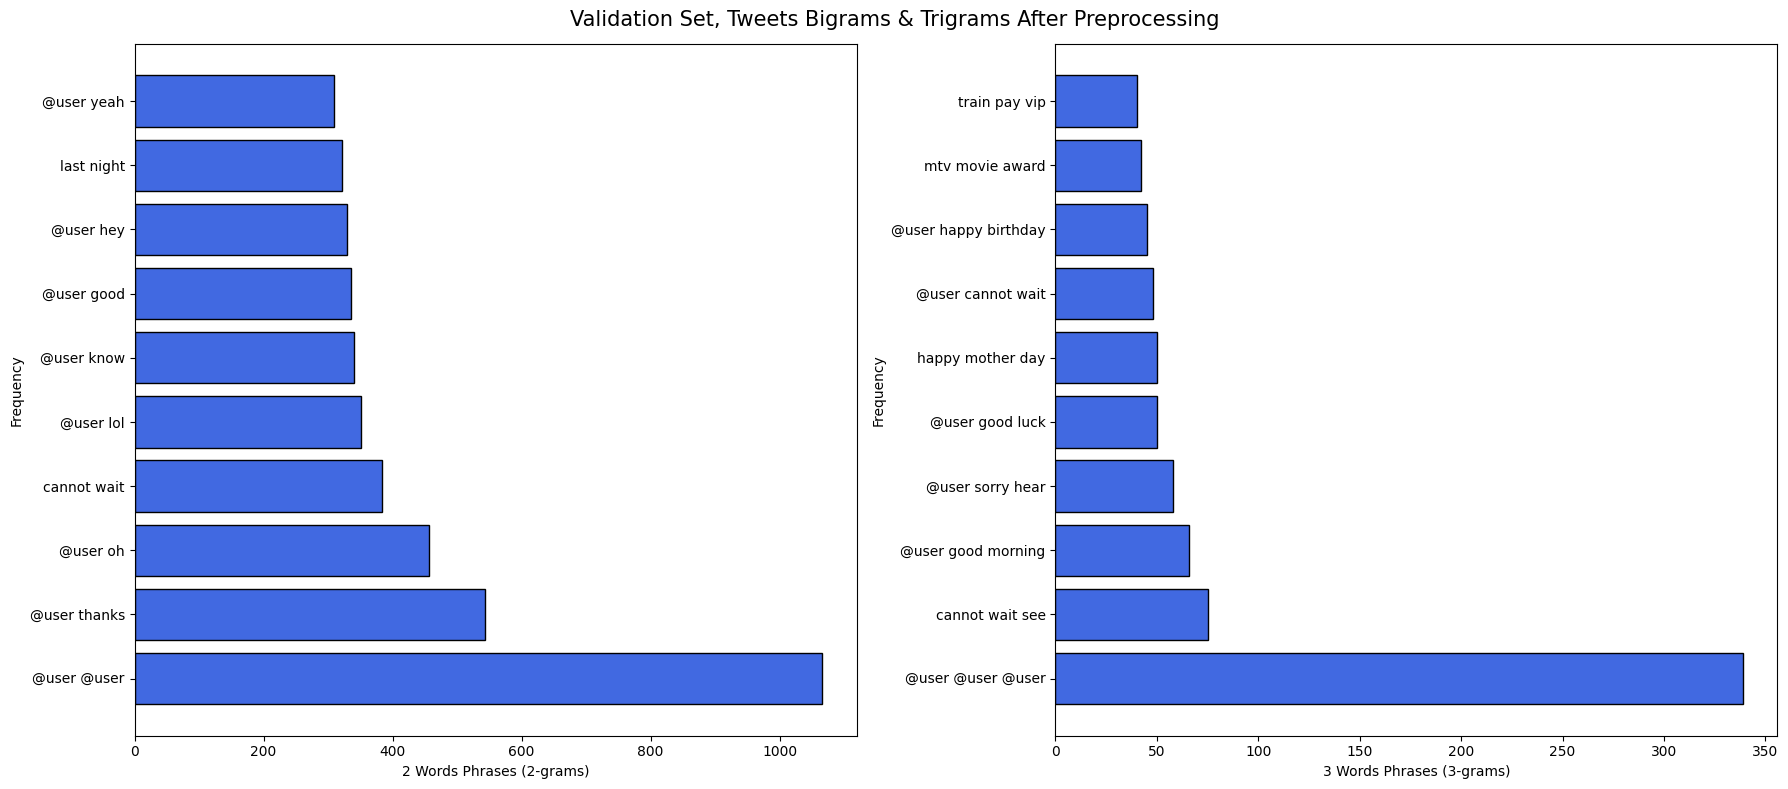

In [45]:
bar_plots_2ngrams = [res for res in get_top_tokens(df_val_cln, top=10, n=2)] + ['2 Words Phrases (2-grams)', 'Frequency']
bar_plots_3ngrams = [res for res in get_top_tokens(df_val_cln, top=10, n=3)] + ['3 Words Phrases (3-grams)', 'Frequency']

subplot_bars(bar_plots_2ngrams, bar_plots_3ngrams, 'Validation Set, Tweets Bigrams & Trigrams After Preprocessing', bary=True)

## Feature Extraction: TF-IDF Hyperparameters Tuning

### Function that calculates **Accuracy**, **Precission**, **Recall** and **F1 scores** and returns a dictionary object

In [22]:
def calc_model_score(y_true, y_pred):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }
    return metrics

### Function that creates multiple subplot bar graphs to display model scores for each hyperparameter configuration 

In [23]:
def subplot_scores(metrics_list, titles, title, rows=2, cols=2, figsize=(12,10)):
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    fig.suptitle(title, fontsize=15)
    
    if rows * cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    colors_list = ['#1C77C3', '#F34213', '#E0CA3C', '#3E2F5B']

    for ax, metrics, sub_title in zip(axes, metrics_list, titles):
        bars = ax.bar(list(metrics.keys()), [value * 100 for value in metrics.values()], color=colors_list, edgecolor='black')

        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f"{height:.2f}%", ha='center', va='bottom')
        
        ax.set_ylabel("Score")
        ax.set_ylim(0, 110)
        ax.set_title(sub_title)
        
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

### Function that calculates the learning curve, given a model configuration

In [24]:
def calc_learning_curve(model_conf, X, Y):
    train_sizes, train_scores, cv_scores = learning_curve(model_conf, X, Y, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10))

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    cv_mean = np.mean(cv_scores, axis=1)
    cv_std = np.std(cv_scores, axis=1)

    return train_sizes, train_mean, train_std, cv_mean, cv_std

### Function that plots the learning curve graph

In [25]:
def plot_learning_curve(train_sizes, train_mean, train_std, cv_mean, cv_std, title):
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label="Training Score")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.plot(train_sizes, cv_mean, 'o-', color='green', label="Validation Score")
    plt.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.1, color='green')
    
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy Score")
    plt.title(title)
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

### Function that calculates the ROC curve

In [26]:
def calc_roc_curve(y, y_pred):
    fpr, tpr, _ = roc_curve(y, y_pred)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

### Function that plots the ROC curve

In [27]:
def plot_roc_curve(fpr, tpr, roc_auc, estimator_name):
    display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=estimator_name)
    display.plot()
    plt.show()

### Function that calculates the confusion matrix, given the classification labels

In [28]:
def calc_confusion_matrix(y, y_pred, clf):
    return confusion_matrix(y, y_pred, labels=clf.classes_)

### Function that plots the confusion matrix

In [29]:
def plot_confusion_matrix(cm, clf):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
    disp.plot()
    plt.show()

#### The acronyms used on preprocessing experimentations are the following: 

#### - **NPR**: No Preprocessing
#### - **PRFS**: Preprocessing & Filtering Stopwords
#### - **PRPS**: Preprocessing & Preserving Stopwords

### Preprocessing without filtering stop words

In [247]:
df_train_cln = clean_dataset(df_train, filter_stopwords=False)
df_val_cln = clean_dataset(df_val, filter_stopwords=False)
df_test_cln = clean_dataset(df_test, filter_stopwords=False, filter_rows=False)

X_train_prep, y_train_prep = df_train_cln['Text'], df_train_cln['Label']
X_val_prep, y_val_prep = df_val_cln['Text'], df_val_cln['Label']
X_test_prep = df_test_cln['Text']

In [248]:
print(f"X train Preprocessed Dimensions: {X_train_prep.shape}")
print(f"y train Preprocessed Dimensions: {y_train_prep.shape}")

print(f"X_val Preprocessed Dimensions: {X_val_prep.shape}")
print(f"y val Preprocessed Dimensions: {y_val_prep.shape}")

print(f"X test Preprocessed Dimensions: {X_test_prep.shape}")

X train Preprocessed Dimensions: (148388,)
y train Preprocessed Dimensions: (148388,)
X_val Preprocessed Dimensions: (42396,)
y val Preprocessed Dimensions: (42396,)
X test Preprocessed Dimensions: (21199,)


### Word2Vec

In [1]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove*.zip

--2025-04-06 00:04:18--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-04-06 00:04:19--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-04-06 00:04:20--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [114]:
glove_input_file = 'glove.6B.300d.txt'
word2vec_output_file = 'glv_with_w2v_format.txt'

glove2word2vec(glove_input_file, word2vec_output_file)
glove = KeyedVectors.load_word2vec_format(word2vec_output_file)

embeddings_dim = 300

In [249]:
tknzr = TweetTokenizer()

X_train_prep_toks = X_train_prep.apply(lambda x: tknzr.tokenize(x))
X_val_prep_toks = X_val_prep.apply(lambda x: tknzr.tokenize(x))
X_test_prep_toks = X_test_prep.apply(lambda x: tknzr.tokenize(x))

In [250]:
X_train_prep_toks

0         [@user, dude, i, am, so, bummed, you, are, lea...
1         [oh, my, god, a, severed, foot, wa, foun, in, ...
2         [i, end, up, quotdog, dialingquot, sumtimes, w...
3                                  [@user, meeeee, toooooo]
4         [i, wa, hoping, i, could, stay, home, and, wor...
                                ...                        
148383    [just, love, the, jonas, brother, it, tooo, ba...
148384    [another, day, gone, bytime, is, moving, so, f...
148385    [fuck, college, i, am, just, going, to, marry,...
148386    [zomgz, new, song, ftw, remember, that, night,...
148387    [arbys, took, down, their, roastburger, coupon...
Name: Text, Length: 148388, dtype: object

In [251]:
def tokens_to_embeddings(df_tokens, glove_model, embeddings_dim=300):
    embeddings = []
    for tokens in df_tokens:
        if len(tokens) == 0:
            embeddings.append(torch.zeros(1, embeddings_dim))
        else:
            vecs = []
            for token in tokens:
                vecs.append(glove_model[token] if token in glove_model else np.zeros(embeddings_dim))
            embeddings.append(torch.tensor(np.array(vecs), dtype=torch.float32))
    return embeddings

In [252]:
X_train_vec = tokens_to_embeddings(X_train_prep_toks, glove)
X_val_vec = tokens_to_embeddings(X_val_prep_toks, glove)
X_test_vec = tokens_to_embeddings(X_test_prep_toks, glove)

In [253]:
X_train_vec[0]

tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.4488, -0.2080, -0.3821,  ...,  0.0830,  0.0829,  0.7005],
        [-0.1329,  0.1699, -0.1436,  ..., -0.2378,  0.1477,  0.6290],
        ...,
        [-0.2843,  0.0480, -0.1506,  ..., -0.0901,  0.0169,  0.2928],
        [-0.2359,  0.3831,  0.1083,  ..., -0.7919, -0.0860, -0.1466],
        [-0.0116, -0.1176,  0.2382,  ..., -0.3742, -0.2146,  0.1517]])

In [254]:
X_train_padded = torch.stack([torch.mean(sentence, dim=0) for sentence in X_train_vec])
X_val_padded = torch.stack([torch.mean(sentence, dim=0) for sentence in X_val_vec])
X_test_padded = torch.stack([torch.mean(sentence, dim=0) for sentence in X_test_vec])

In [214]:
import torch

def mean_pool_with_masking(embeddings):
    # Mask to check where embeddings are non-zero (assuming zero is the padding value)
    mask = (embeddings != 0).float()  # This creates a mask where non-zero embeddings are 1, padding is 0
    
    # Count how many valid tokens there are (non-zero embeddings)
    valid_token_count = mask.sum(dim=0)  # This counts non-zero tokens across the batch dimension
    
    # Avoid division by zero by adding a small number where valid_token_count is zero
    valid_token_count = valid_token_count + (valid_token_count == 0).float()
    
    # Sum the embeddings and divide by the valid token count to get the mean embedding
    mean_embedding = embeddings.sum(dim=0) / valid_token_count  # Sum over token dimension (dim=0)
    
    return mean_embedding

# Assuming X_train_vec, X_val_vec, and X_test_vec are lists of tensors where each tensor has shape [num_tokens, embedding_dim]
X_train_pooled = torch.stack([mean_pool_with_masking(sentence) for sentence in X_train_vec])
X_val_pooled = torch.stack([mean_pool_with_masking(sentence) for sentence in X_val_vec])
X_test_pooled = torch.stack([mean_pool_with_masking(sentence) for sentence in X_test_vec])

# Now X_train_pooled, X_val_pooled, and X_test_pooled will each have the shape [num_sentences, embedding_dim]


In [229]:
import torch

def max_pool_with_masking(embeddings):
    # Mask to check where embeddings are non-zero (assuming zero is the padding value)
    mask = (embeddings != 0).float()

    # Apply the mask to ignore zero embeddings (padding tokens)
    masked_embeddings = embeddings * mask

    # Max pooling: Find the max for each dimension (ignores zeros)
    max_embedding = masked_embeddings.max(dim=0)[0]  # Get the max across tokens (along the 0th axis)

    return max_embedding

# Apply max pooling with masking for each sentence in your dataset
X_train_max_pooled = torch.stack([max_pool_with_masking(sentence) for sentence in X_train_vec])
X_val_max_pooled = torch.stack([max_pool_with_masking(sentence) for sentence in X_val_vec])
X_test_max_pooled = torch.stack([max_pool_with_masking(sentence) for sentence in X_test_vec])


In [230]:
X_train_pooled.shape

torch.Size([148339, 300])

In [255]:
x_train_tensor = X_train_padded.view(X_train_padded.size(0), -1)
x_val_tensor = X_val_padded.view(X_val_padded.size(0), -1)
x_test_tensor = X_test_padded.view(X_test_padded.size(0), -1)

y_train_tensor = torch.tensor(y_train_prep.values).float().unsqueeze(1)
y_val_tensor = torch.tensor(y_val_prep.values).float().unsqueeze(1)

In [256]:
x_train_tensor.shape

torch.Size([148388, 300])

In [257]:
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [258]:
def train_epoch(model, train_loader, loss_func, optimizer):
    model.train()
    batch_losses = []

    for x_batch, y_batch in train_loader:
        y_pred = model(x_batch)
        loss = loss_func(y_pred, y_batch)
        batch_losses.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    return sum(batch_losses) / len(batch_losses)

In [259]:
def evaluate(model, x_val_tensor, y_val_tensor, loss_func):
    model.eval()
    
    with torch.no_grad():
        y_val_pred = torch.sigmoid(model(x_val_tensor))
        y_val_pred = (y_val_pred > 0.5).float()
        y_val_pred = y_val_pred.cpu().numpy()
        y_val_true = y_val_tensor.cpu().numpy()

        accuracy = accuracy_score(y_val_true, y_val_pred)
        precision = precision_score(y_val_true, y_val_pred)
        recall = recall_score(y_val_true, y_val_pred)
        f1 = f1_score(y_val_true, y_val_pred)

    return accuracy, precision, recall, f1

In [127]:
class Hidden2Net(nn.Module):
    def __init__(self, D_in, H1=128, H2=64, D_out=1, dropout_rate=0.5):
        super(Hidden2Net, self).__init__()
        self.linear1 = nn.Linear(D_in, H1)
        self.linear2 = nn.Linear(H1, H2)
        self.linear3 = nn.Linear(H2, D_out)
    
    def forward(self, x):
        x = torch.relu(self.linear1(x))
        x = torch.relu(self.linear2(x))
        out = self.linear3(x)
        return out

In [128]:
D_in = x_train_tensor.shape[1]
model = Hidden2Net(D_in=D_in, H1=128, H2=64, D_out=1, dropout_rate=0.5)

loss_func = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    train_loss = train_epoch(model, train_loader, loss_func, optimizer)
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.5f}")
    accuracy, precision, recall, f1 = evaluate(model, x_val_tensor, y_val_tensor, loss_func)
    print(f"Validation - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

Epoch 1: Train Loss = 0.56195
Validation - Accuracy: 0.7186, Precision: 0.7344, Recall: 0.6849, F1: 0.7088
Epoch 2: Train Loss = 0.50478
Validation - Accuracy: 0.7232, Precision: 0.7033, Recall: 0.7721, F1: 0.7361
Epoch 3: Train Loss = 0.42305
Validation - Accuracy: 0.7144, Precision: 0.7058, Recall: 0.7353, F1: 0.7203
Epoch 4: Train Loss = 0.32514
Validation - Accuracy: 0.7073, Precision: 0.6916, Recall: 0.7485, F1: 0.7189
Epoch 5: Train Loss = 0.24547
Validation - Accuracy: 0.7002, Precision: 0.7085, Recall: 0.6806, F1: 0.6943


In [129]:
class Hidden3Net(nn.Module):
    def __init__(self, D_in, H1=128, H2=64, H3=32, D_out=1, dropout_rate=0.5):
        super(Hidden3Net, self).__init__()
        self.linear1 = nn.Linear(D_in, H1)
        self.linear2 = nn.Linear(H1, H2)
        self.linear3 = nn.Linear(H2, H3)
        self.linear4 = nn.Linear(H3, D_out)
    
    def forward(self, x):
        x = torch.relu(self.linear1(x))
        x = torch.relu(self.linear2(x))
        x = torch.relu(self.linear3(x))
        out = self.linear4(x)
        return out

In [130]:
model = Hidden3Net(D_in=D_in, H1=128, H2=64, H3=32, D_out=1, dropout_rate=0.5)

loss_func = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    train_loss = train_epoch(model, train_loader, loss_func, optimizer)
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.5f}")
    accuracy, precision, recall, f1 = evaluate(model, x_val_tensor, y_val_tensor, loss_func)
    print(f"Validation - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

Epoch 1: Train Loss = 0.56151
Validation - Accuracy: 0.7197, Precision: 0.7084, Recall: 0.7469, F1: 0.7271
Epoch 2: Train Loss = 0.50342
Validation - Accuracy: 0.7262, Precision: 0.7221, Recall: 0.7354, F1: 0.7287
Epoch 3: Train Loss = 0.42367
Validation - Accuracy: 0.7152, Precision: 0.6922, Recall: 0.7750, F1: 0.7313
Epoch 4: Train Loss = 0.32945
Validation - Accuracy: 0.7114, Precision: 0.7022, Recall: 0.7342, F1: 0.7178
Epoch 5: Train Loss = 0.25589
Validation - Accuracy: 0.7029, Precision: 0.7083, Recall: 0.6901, F1: 0.6991


In [ ]:
class Hidden3NetExtended(nn.Module):
    def __init__(self, D_in, H1=128, H2=64, H3=32, D_out=1, dropout_rate=0.5):
        super(Hidden3NetExtended, self).__init__()
        
        self.linear1 = nn.Linear(D_in, H1)
        self.bn1 = nn.BatchNorm1d(H1)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.linear2 = nn.Linear(H1, H2)
        self.bn2 = nn.BatchNorm1d(H2)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        self.linear3 = nn.Linear(H2, H3)
        self.bn3 = nn.BatchNorm1d(H3)
        self.dropout3 = nn.Dropout(dropout_rate)
        
        self.linear4 = nn.Linear(H3, D_out)
    
    def forward(self, x):
        x = torch.relu(self.bn1(self.linear1(x)))
        x = self.dropout1(x)
        
        x = torch.relu(self.bn2(self.linear2(x)))
        x = self.dropout2(x)
        
        x = torch.relu(self.bn3(self.linear3(x)))
        x = self.dropout3(x)

        out = self.linear4(x)
        return out

In [ ]:
D_in = x_train_tensor.shape[1]
H1, H2, H3 = 128, 64, 32
D_out = 1

model = Hidden3NetExtended(D_in=D_in, H1=H1, H2=H2, H3=H3, D_out=D_out, dropout_rate=0.5)

output = model(x_train_tensor)
loss_func = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    train_loss = train_epoch(model, train_loader, loss_func, optimizer)
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.5f}")

    accuracy, precision, recall, f1 = evaluate(model, x_val_tensor, y_val_tensor, loss_func)
    print(f"Validation - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

Epoch 1: Train Loss = 0.61393
Validation - Accuracy: 0.6979, Precision: 0.6784, Recall: 0.7526, F1 Score: 0.7136
Epoch 2: Train Loss = 0.58430
Validation - Accuracy: 0.7026, Precision: 0.6875, Recall: 0.7427, F1 Score: 0.7140
Epoch 3: Train Loss = 0.57449
Validation - Accuracy: 0.7074, Precision: 0.7145, Recall: 0.6910, F1 Score: 0.7026
Epoch 4: Train Loss = 0.56390
Validation - Accuracy: 0.7114, Precision: 0.7086, Recall: 0.7181, F1 Score: 0.7133
Epoch 5: Train Loss = 0.55487
Validation - Accuracy: 0.7165, Precision: 0.7298, Recall: 0.6876, F1 Score: 0.7081


In [175]:
class Hidden4Net(nn.Module):
    def __init__(self, D_in, H1=128, H2=64, H3=32, H4=16, D_out=1, dropout_rate=0.5):
        super(Hidden4Net, self).__init__()
        
        self.linear1 = nn.Linear(D_in, H1)
        self.bn1 = nn.BatchNorm1d(H1)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.linear2 = nn.Linear(H1, H2)
        self.bn2 = nn.BatchNorm1d(H2)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        self.linear3 = nn.Linear(H2, H3)
        self.bn3 = nn.BatchNorm1d(H3)
        self.dropout3 = nn.Dropout(dropout_rate)
        
        self.linear4 = nn.Linear(H3, H4)
        self.bn4 = nn.BatchNorm1d(H4)
        self.dropout4 = nn.Dropout(dropout_rate)
        
        self.linear5 = nn.Linear(H4, D_out)
    
    def forward(self, x):
        x = torch.relu(self.bn1(self.linear1(x)))
        x = self.dropout1(x)
        
        x = torch.relu(self.bn2(self.linear2(x)))
        x = self.dropout2(x)
        
        x = torch.relu(self.bn3(self.linear3(x)))
        x = self.dropout3(x)
        
        x = torch.relu(self.bn4(self.linear4(x)))
        x = self.dropout4(x)
        
        out = self.linear5(x)
        
        return out

In [176]:
D_in = x_train_tensor.shape[1]
H1, H2, H3, H4 = 128, 64, 32, 16
D_out = 1
dropout_rate = 0.5

model = Hidden4Net(D_in=D_in, H1=H1, H2=H2, H3=H3, H4=H4, D_out=D_out, dropout_rate=dropout_rate)

loss_func = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    model.train()
    train_loss = train_epoch(model, train_loader, loss_func, optimizer)
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.5f}")

    model.eval()
    accuracy, precision, recall, f1 = evaluate(model, x_val_tensor, y_val_tensor, loss_func)
    print(f"Validation - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

Epoch 1: Train Loss = 0.59895
Validation - Accuracy: 0.7212, Precision: 0.7038, Recall: 0.7637, F1 Score: 0.7325
Epoch 2: Train Loss = 0.57370
Validation - Accuracy: 0.7243, Precision: 0.7458, Recall: 0.6806, F1 Score: 0.7117
Epoch 3: Train Loss = 0.56693
Validation - Accuracy: 0.7304, Precision: 0.7181, Recall: 0.7586, F1 Score: 0.7378
Epoch 4: Train Loss = 0.56166
Validation - Accuracy: 0.7326, Precision: 0.7368, Recall: 0.7236, F1 Score: 0.7302
Epoch 5: Train Loss = 0.55928
Validation - Accuracy: 0.7369, Precision: 0.7264, Recall: 0.7603, F1 Score: 0.7429


In [ ]:
import torch
import torch.nn as nn

class BetterFeedForwardNet(nn.Module):
    def __init__(self, D_in, H1=256, H2=128, H3=64, D_out=1, dropout_rate=0.4, use_leaky=False):
        super(BetterFeedForwardNet, self).__init__()
        activation = nn.LeakyReLU() if use_leaky else nn.ReLU()
        
        self.fc1 = nn.Linear(D_in, H1)
        self.bn1 = nn.BatchNorm1d(H1)
        self.act1 = activation
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.fc2 = nn.Linear(H1, H2)
        self.bn2 = nn.BatchNorm1d(H2)
        self.act2 = activation
        self.dropout2 = nn.Dropout(dropout_rate)
        
        self.fc3 = nn.Linear(H2, H3)
        self.bn3 = nn.BatchNorm1d(H3)
        self.act3 = activation
        self.dropout3 = nn.Dropout(dropout_rate)
        
        # Optionally, you can add a residual connection from fc1 to fc3 if dimensions match:
        # self.res_fc = nn.Linear(H1, H3)  # Uncomment and use if desired
        
        self.out_fc = nn.Linear(H3, D_out)
        
    def forward(self, x):
        # x is expected to have shape: (batch_size, D_in)
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.act3(x)
        x = self.dropout3(x)
        # If a residual connection is desired, combine:
        # x = x + self.res_fc(x_from_fc1)   <-- requires saving intermediate output
        
        out = self.out_fc(x)
        return out

# Example usage:
# Assume x_train_tensor is a flattened tensor of shape (batch_size, D_in)
D_in = x_train_tensor.shape[1]  # e.g., if using averaged embeddings, D_in = 100; if flattened, adjust accordingly
model = BetterFeedForwardNet(D_in, H1=256, H2=128, H3=64, D_out=1, dropout_rate=0.5, use_leaky=True)

# Define loss and optimizer
loss_func = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

# Training loop sample (using your train_epoch and evaluate functions)
for epoch in range(5):
    train_loss = train_epoch(model, train_loader, loss_func, optimizer)
    acc, prec, rec, f1 = evaluate(model, x_val_tensor, y_val_tensor, loss_func)
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.5f}; Val Acc = {acc:.4f}, Prec = {prec:.4f}, Rec = {rec:.4f}, F1 = {f1:.4f}")

# Once trained, you can use the model to predict on the test set as before.
model.eval()
with torch.no_grad():
    test_logits = model(x_test_tensor)
    test_probs = torch.sigmoid(test_logits)
    test_pred = (test_probs > 0.5).float()
print("Test predictions:", test_pred)


Epoch 1: Train Loss = 0.57608; Val Acc = 0.7192, Prec = 0.7139, Rec = 0.7317, F1 = 0.7227


KeyboardInterrupt: 

In [ ]:
def plot_metrics(epochs, accuracies, precisions, recalls, f1_scores):
    metrics = {'Accuracy': accuracies, 'Precision': precisions, 'Recall': recalls, 'F1 Score': f1_scores}
    colors = {'Accuracy': 'tab:blue', 'Precision': 'tab:orange', 'Recall': 'tab:green', 'F1 Score': 'tab:red'}
    
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    for i, (metric_name, metric_values) in enumerate(metrics.items()):
        row, col = divmod(i, 2)
        axs[row, col].plot(epochs, metric_values, label=metric_name, color=colors[metric_name])
        axs[row, col].set_title(f'{metric_name} per Epoch')
        axs[row, col].set_xlabel('Epochs')
        axs[row, col].set_ylabel(metric_name)
        axs[row, col].grid(True)

    plt.tight_layout()
    plt.show()

In [273]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR

# -------------------------
# Model with an additional hidden layer
# -------------------------
class BetterFeedForwardNet(nn.Module):
    def __init__(self, D_in, H1=512, H2=256, H3=128, H4=64, D_out=1, dropout_rate=0.5, use_leaky=True):
        super(BetterFeedForwardNet, self).__init__()
        activation = nn.LeakyReLU() if use_leaky else nn.ReLU()
        
        # First hidden layer
        self.fc1 = nn.Linear(D_in, H1)
        self.bn1 = nn.BatchNorm1d(H1)
        self.act1 = activation
        self.dropout1 = nn.Dropout(dropout_rate)
        
        # Second hidden layer
        self.fc2 = nn.Linear(H1, H2)
        self.bn2 = nn.BatchNorm1d(H2)
        self.act2 = activation
        self.dropout2 = nn.Dropout(dropout_rate)
        
        # Third hidden layer
        self.fc3 = nn.Linear(H2, H3)
        self.bn3 = nn.BatchNorm1d(H3)
        self.act3 = activation
        self.dropout3 = nn.Dropout(dropout_rate)
        
        # # Fourth hidden layer (New)
        # self.fc4 = nn.Linear(H3, H4)
        # self.bn4 = nn.BatchNorm1d(H4)
        # self.act4 = activation
        # self.dropout4 = nn.Dropout(dropout_rate)
        
        # Output layer
        self.out_fc = nn.Linear(H3, D_out)
        
    def forward(self, x):
        # First layer
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.dropout1(x)
        
        # Second layer
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.dropout2(x)
        
        # Third layer
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.act3(x)
        x = self.dropout3(x)
        
        # # Fourth layer
        # x = self.fc4(x)
        # x = self.bn4(x)
        # x = self.act4(x)
        # x = self.dropout4(x)
        
        # Output layer
        out = self.out_fc(x)
        return out

# -------------------------
# Example Setup
# -------------------------
D_in = x_train_tensor.shape[1]
model = BetterFeedForwardNet(D_in)

loss_func = nn.BCEWithLogitsLoss()
optimizer = optim.RAdam(model.parameters(), lr=1e-3)
# scheduler = OneCycleLR(optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=5)

# -------------------------
# Training and Evaluation
# -------------------------

def train_epoch(model, loader, loss_func, optimizer, scheduler):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        preds = model(xb).squeeze(1)
        loss = loss_func(preds, yb.squeeze(1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    # scheduler.step()  # <-- move scheduler.step() *after* the epoch
    return total_loss / len(loader)

def evaluate(model, x_val, y_val, loss_func):
    model.eval()
    with torch.no_grad():
        preds = model(x_val).squeeze(1)
        loss = loss_func(preds, y_val.squeeze(1))  # <-- squeeze labels
        probs = torch.sigmoid(preds)
        preds_binary = (probs > 0.5).float()
        
        acc = (preds_binary == y_val.squeeze(1)).float().mean().item()
        precision = (preds_binary * y_val.squeeze(1)).sum() / (preds_binary.sum() + 1e-8)
        recall = (preds_binary * y_val.squeeze(1)).sum() / (y_val.squeeze(1).sum() + 1e-8)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
        
        return acc, precision.item(), recall.item(), f1.item()

# -------------------------
# Training Loop
# -------------------------

for epoch in range(50):
    train_loss = train_epoch(model, train_loader, loss_func, optimizer, None)
    acc, prec, rec, f1 = evaluate(model, x_val_tensor, y_val_tensor, loss_func)
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.5f}; Val Acc = {acc:.4f}, Prec = {prec:.4f}, Rec = {rec:.4f}, F1 = {f1:.4f}")

# -------------------------
# Testing
# -------------------------

model.eval()
with torch.no_grad():
    test_logits = model(x_test_tensor).squeeze(1)
    test_probs = torch.sigmoid(test_logits)
    test_pred = (test_probs > 0.5).float()

print("Test predictions:", test_pred)


Epoch 1: Train Loss = 0.55911; Val Acc = 0.7427, Prec = 0.7402, Rec = 0.7479, F1 = 0.7440
Epoch 2: Train Loss = 0.52781; Val Acc = 0.7498, Prec = 0.7699, Rec = 0.7128, F1 = 0.7402
Epoch 3: Train Loss = 0.51975; Val Acc = 0.7521, Prec = 0.7420, Rec = 0.7731, F1 = 0.7573
Epoch 4: Train Loss = 0.51223; Val Acc = 0.7574, Prec = 0.7531, Rec = 0.7659, F1 = 0.7595
Epoch 5: Train Loss = 0.50661; Val Acc = 0.7607, Prec = 0.7743, Rec = 0.7359, F1 = 0.7546
Epoch 6: Train Loss = 0.50018; Val Acc = 0.7616, Prec = 0.7729, Rec = 0.7409, F1 = 0.7566
Epoch 7: Train Loss = 0.49708; Val Acc = 0.7605, Prec = 0.7440, Rec = 0.7943, F1 = 0.7684


KeyboardInterrupt: 

In [133]:
def suggest_hyperparameters(trial):
    optimizer_name = trial.suggest_categorical("optimizer_name", ["Adam", "AdamW", "SGD"])
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-5, 1e-1)
    return optimizer_name, learning_rate

In [236]:
def objective(trial):
    optimizer_name, learning_rate = suggest_hyperparameters(trial)
    D_in = x_train_tensor.shape[1]
    H1 = trial.suggest_int("H1", 64, 256)
    H2 = trial.suggest_int("H2", 32, 128)
    H3 = trial.suggest_int("H3", 16, 64)
    model = Hidden3NetExtended(D_in, H1, H2, H3, D_out=1, dropout_rate=0.5)
    loss_func = nn.BCEWithLogitsLoss()
    
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    
    best_val_acc = 0.0
    for epoch in range(5):
        train_loss = train_epoch(model, train_loader, loss_func, optimizer)
        val_acc, val_prec, val_rec, val_f1 = evaluate(model, x_val_tensor, y_val_tensor, loss_func)
        print(f"Trial {trial.number} Epoch {epoch+1}: Train Loss = {train_loss:.5f}, Val Acc = {val_acc:.4f}, "
              f"Prec = {val_prec:.4f}, Rec = {val_rec:.4f}, F1 = {val_f1:.4f}")
        best_val_acc = max(best_val_acc, val_acc)
    return best_val_acc

In [ ]:
study = optuna.create_study(direction="maximize", study_name="sentiment_tuning")
study.optimize(objective, n_trials=20, n_jobs=4)

print("Number of finished trials:", len(study.trials))
print("Best trial:")

trial = study.best_trial

print(f"  Validation Accuracy: {trial.value:.4f}")
print("  Best parameters:")

for key, value in trial.params.items():
    print(f"    {key}: {value}")

### Storing the label predictions among with the tweet IDs in a CSV file

In [ ]:
# pd.DataFrame({
#     'ID': df_test['ID'],
#     'Label': y_test_pred
# }).to_csv('submission.csv', index=False)